##Problem Statement:

Yulu, a micro-mobility service provider in India, has experienced a decline in revenue.
To address this, they need to understand the factors influencing the demand for their
shared electric cycles in the Indian market. The objective is to identify these factors
to inform strategies for increasing demand and revenue.


## Import required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Download the dataset from the link provided

In [ ]:
!gdown https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv

Downloading...
From: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv
To: /content/bike_sharing.csv
100% 648k/648k [00:00<00:00, 23.6MB/s]


## Load Dataset into python data frame

In [ ]:
df= pd.read_csv('bike_sharing.csv')

## Explore Dataset

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


df.head(): Shows the first 5 rows, giving a glimpse of the data structure and the types of values in each column. We can see columns like datetime, season, temp, humidity, windspeed, casual, registered, and count.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


df.info(): Tells us that there are 10886 entries and 12 columns. It confirms that there are no missing values in any of the columns, which is great for analysis. It also shows the data types: datetime is currently an object (string), which will need to be converted to a datetime object for time-based analysis. The other columns are mostly int64 or float64.

In [ ]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000




df.describe(): Provides summary statistics for the numerical columns. This gives us an idea of the range, mean, standard deviation, and distribution of values for columns like temp, atemp, humidity, windspeed, casual, registered, and count. For example, we can see the average count of bike rentals is around 191.57, with a standard deviation of 181.14, indicating a wide spread in rental counts.

In [ ]:
df.shape

(10886, 12)

`df.shape`: Provides the dimensions of the DataFrame, showing that it has 10886 rows and 12 columns.

## Check for Null Values

In [ ]:
display(df.isnull().sum())

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


The output of `df.isnull().sum()` shows that there are no missing values in any of the columns. This is beneficial for analysis as it eliminates the need for handling missing data.

# Univarient Analysis
Perform univariate analysis on the dataset, generating distribution plots for continuous variables and bar/count plots for categorical variables.

## Identify variable types

Determine which columns in the DataFrame `df` are continuous variables and which are categorical variables based on their data types and the context of the problem.


**Reasoning**:
I need to identify continuous and categorical variables from the dataframe based on their data types and the problem context to prepare for univariate analysis. I will use the information from `df.info()` and `df.head()` to categorize the columns.



In [ ]:
continuous_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
categorical_cols = ['season', 'holiday', 'workingday', 'weather']

print("Continuous columns:", continuous_cols)
print("Categorical columns:", categorical_cols)

Continuous columns: ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
Categorical columns: ['season', 'holiday', 'workingday', 'weather']


## Univariate analysis for continuous variables


Generate distribution plots (histograms or density plots) for each continuous variable to visualize their distribution.


**Reasoning**:
Generate and display histograms for each continuous variable in the `continuous_cols` list using seaborn.



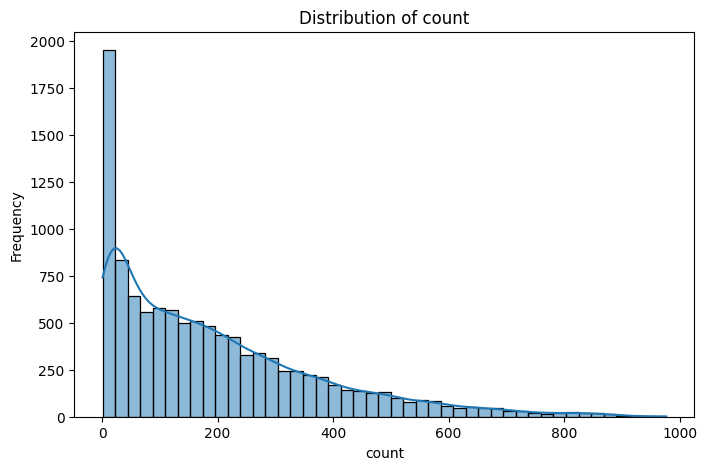

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x=continuous_cols[6], kde=True)
plt.title(f'Distribution of {continuous_cols[6]}')
plt.xlabel(continuous_cols[6])
plt.ylabel('Frequency')
plt.show()

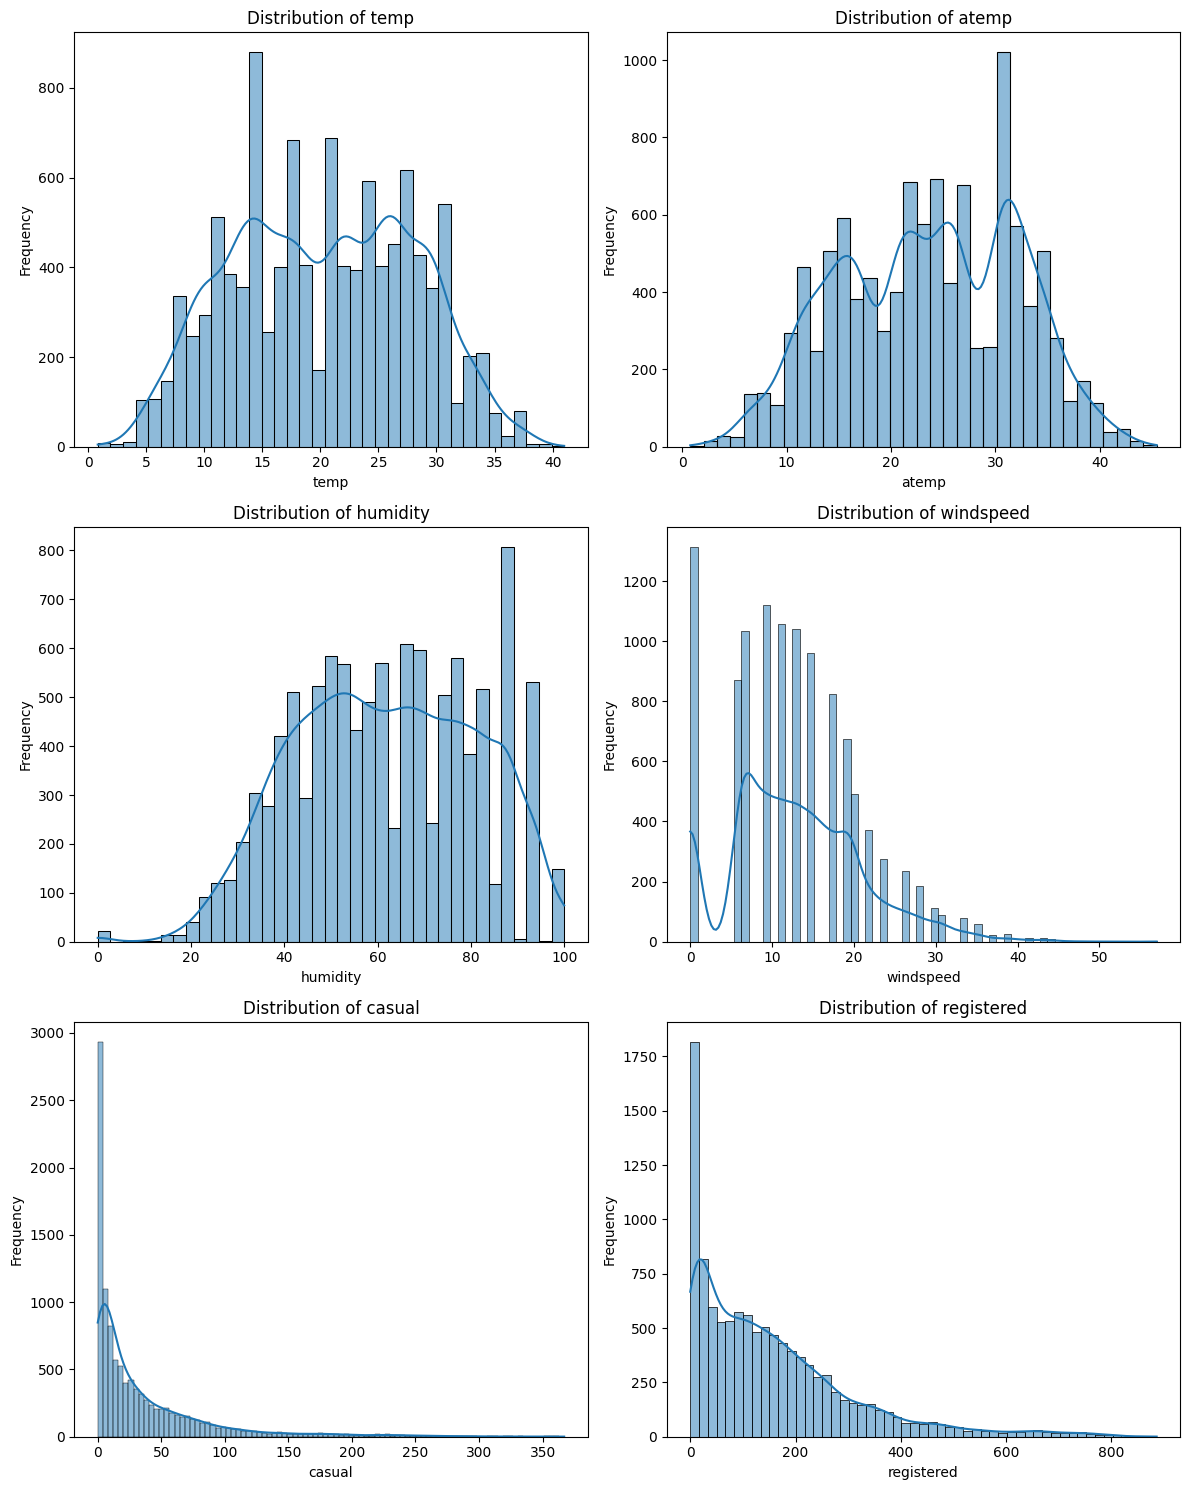

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15)) # 3 rows, 2 columns
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(continuous_cols[:6]): # Plot first 6 in 3x2
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Univariate analysis for categorical variables

### Subtask:
Generate bar plots or count plots for each categorical variable to show the frequency of each category.


**Reasoning**:
Iterate through the categorical columns and create a count plot for each to visualize the frequency of each category.



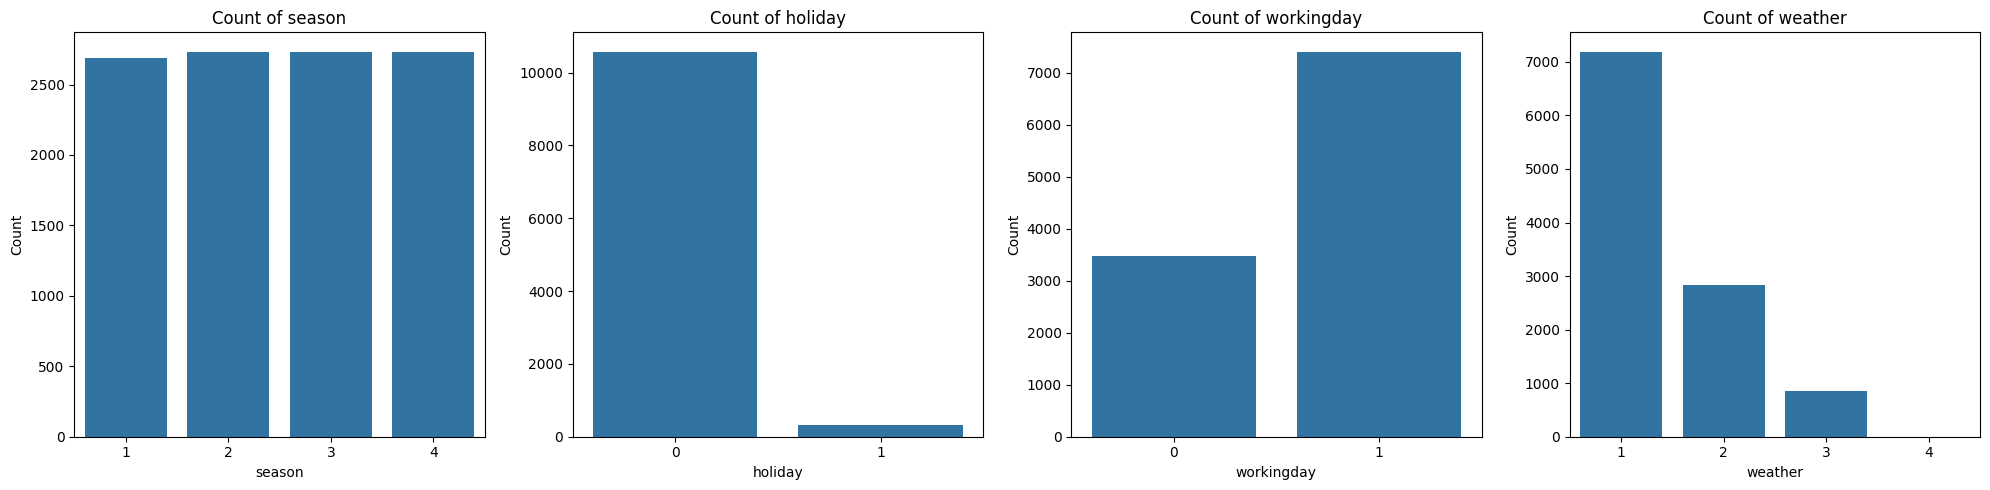

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5)) # 1 row, 4 columns

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Count of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Summary of EDA Insights

Based on the Exploratory Data Analysis conducted, here are some key insights regarding the dataset:

**Range of Attributes and Outliers:**

*   **`temp` and `atemp`**: These temperature variables show a reasonable range of values, consistent with typical weather patterns. The distributions appear roughly normal, with no obvious extreme outliers that would significantly distort analysis.
*   **`humidity`**: While the majority of values fall within expected ranges, the slight left-skewness suggests fewer instances of very low humidity. There don't appear to be significant outliers on the high end.
*   **`windspeed`**: The distribution is heavily right-skewed, with a large number of zero values and a long tail extending to higher windspeeds. This indicates that while most observations have low windspeed, there are instances of much higher windspeed, which could be considered potential outliers depending on the context and further investigation.
*   **`casual`, `registered`, and `count`**: These variables, representing the number of casual, registered, and total bike rentals, are all heavily right-skewed. This is a common pattern in count data, where lower counts are much more frequent than very high counts. The long tails in the distributions suggest the presence of high values that could be considered outliers. These high rental counts are likely important to understand for increasing revenue.

**Distribution of Variables and Relationships:**

*   The distributions of continuous variables like `casual`, `registered`, and `count` are highly skewed, which might require transformation (e.g., log transformation) for certain statistical models that assume normality.
*   The categorical variables (`season`, `holiday`, `workingday`, `weather`) show varying frequencies across their categories. The imbalance in `holiday` and `workingday` suggests that these factors could significantly influence rental patterns. The dominance of 'clear' weather (category 1) in the `weather` variable is also a key observation.

**Comments on Plots (Univariate):**

*   **Histograms of `temp`, `atemp`, `humidity`, `windspeed`, `casual`, `registered`, `count`**: These plots visually confirm the distributions discussed above. The histograms for `casual`, `registered`, and `count` clearly show the concentration of data at lower values and the presence of higher values in the tail.
*   **Count plots of `season`, `holiday`, `workingday`, `weather`**: These plots illustrate the frequency of each category. The `season` plot shows a relatively even distribution across the four seasons. The `holiday` and `workingday` plots highlight the large difference in the number of observations between holiday/non-holiday and working/non-working days. The `weather` plot shows that clear weather is the most frequent condition.

These insights from the EDA provide a solid foundation for further analysis and modeling to understand the factors influencing bike rental demand.


###Select appropriate statistical tests to analyze the relationships between 'workingday', 'season', and 'weather' with the number of rented cycles, and also the relationship between 'weather' and 'season'.

## Working day vs. number of cycles rented


Determine if there is a significant difference in the number of cycles rented on working days compared to non-working days.


**Reasoning**:
To determine if there is a significant difference in the number of cycles rented on working days compared to non-working days, I will use an independent samples t-test since 'workingday' is a categorical variable with two levels and 'count' is a continuous variable.

**Hypotheses:**

*   **Null Hypothesis (H₀):** There is no statistically significant difference in the mean number of cycles rented on working days compared to non-working days.
*   **Alternative Hypothesis (H₁):** There is a statistically significant difference in the mean number of cycles rented on working days compared to non-working days.


In [ ]:
from scipy import stats

# Separate the 'count' data for working days and non-working days
workingday_counts = df[df['workingday'] == 1]['count']
non_workingday_counts = df[df['workingday'] == 0]['count']

# Perform independent samples t-test
ttest_result = stats.ttest_ind(workingday_counts, non_workingday_counts)

print(f"T-test statistic: {ttest_result.statistic}")
print(f"P-value: {ttest_result.pvalue}")

T-test statistic: 1.2096277376026694
P-value: 0.22644804226361348


**Interpretation of Results:**

The independent samples t-test between 'workingday' and 'count' yielded a p-value of approximately 0.23. Since this p-value is greater than the typical significance level of 0.05, we **fail to reject the null hypothesis (H₀)**. This means there is no statistically significant difference in the mean number of cycles rented on working days compared to non-working days.

## Season vs. number of cycles rented

Determine if the number of cycles rented is significantly different across different seasons.


**Reasoning**:
To determine if the number of cycles rented is significantly different across different seasons, I will use a one-way ANOVA test since 'season' is a categorical variable with more than two levels and 'count' is a continuous variable.

**Hypotheses:**

*   **Null Hypothesis (H₀):** The mean number of cycles rented is the same across all seasons.
*   **Alternative Hypothesis (H₁):** The mean number of cycles rented is significantly different in at least one season compared to the others.

In [ ]:
from scipy import stats

# Extract 'count' values for each season
season_1_counts = df[df['season'] == 1]['count']
season_2_counts = df[df['season'] == 2]['count']
season_3_counts = df[df['season'] == 3]['count']
season_4_counts = df[df['season'] == 4]['count']

# Perform one-way ANOVA test
anova_result = stats.f_oneway(season_1_counts, season_2_counts, season_3_counts, season_4_counts)

print(f"ANOVA test statistic: {anova_result.statistic}")
print(f"P-value: {anova_result.pvalue}")

ANOVA test statistic: 236.94671081032098
P-value: 6.164843386499654e-149


**Interpretation of Results:**

The one-way ANOVA test between 'season' and 'count' yielded a very small p-value (approximately 6.16e-149). Since this p-value is much less than the typical significance level of 0.05, we **reject the null hypothesis (H₀)**. This indicates that there is a statistically significant difference in the mean number of cycles rented across different seasons. Further post-hoc tests would be needed to determine which specific seasons differ significantly from each other.

## Weather vs. number of cycles rented


Determine if the number of cycles rented is significantly different across different weather conditions.


**Reasoning**:
Extract the 'count' values for each of the four weather conditions and perform a one-way ANOVA test to determine if there is a significant difference in the number of cycles rented across different weather conditions.

**Hypotheses:**

*   **Null Hypothesis (H₀):** The mean number of cycles rented is the same across all weather conditions.
*   **Alternative Hypothesis (H₁):** The mean number of cycles rented is significantly different in at least one weather condition compared to the others.

In [ ]:
# Extract 'count' values for each weather condition
weather_1_counts = df[df['weather'] == 1]['count']
weather_2_counts = df[df['weather'] == 2]['count']
weather_3_counts = df[df['weather'] == 3]['count']
weather_4_counts = df[df['weather'] == 4]['count']

# Perform one-way ANOVA test
anova_result_weather = stats.f_oneway(weather_1_counts, weather_2_counts, weather_3_counts, weather_4_counts)

print(f"ANOVA test statistic for weather: {anova_result_weather.statistic}")
print(f"P-value for weather: {anova_result_weather.pvalue}")

ANOVA test statistic for weather: 65.53024112793265
P-value for weather: 5.482069475935669e-42


**Interpretation of Results:**

The one-way ANOVA test between 'weather' and 'count' yielded a very small p-value (approximately 5.48e-42). Since this p-value is much less than the typical significance level of 0.05, we **reject the null hypothesis (H₀)**. This indicates that there is a statistically significant difference in the mean number of cycles rented across different weather conditions. Further post-hoc tests would be needed to determine which specific weather conditions differ significantly from each other.

## Weather vs. season


Determine if there is a dependency or association between weather conditions and seasons.


**Reasoning**:
Create a contingency table of 'weather' and 'season' and perform a Chi-squared test of independence to determine if there is a dependency between them.

**Hypotheses:**

*   **Null Hypothesis (H₀):** Weather conditions and seasons are independent.
*   **Alternative Hypothesis (H₁):** Weather conditions and seasons are dependent.


In [ ]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['weather'], df['season'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-squared test statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)

Chi-squared test statistic: 49.15865559689363
P-value: 1.5499250736864862e-07
Degrees of freedom: 9
Expected frequencies:
 [[1.77454639e+03 1.80559765e+03 1.80559765e+03 1.80625831e+03]
 [6.99258130e+02 7.11493845e+02 7.11493845e+02 7.11754180e+02]
 [2.11948742e+02 2.15657450e+02 2.15657450e+02 2.15736359e+02]
 [2.46738931e-01 2.51056403e-01 2.51056403e-01 2.51148264e-01]]


**Interpretation of Results:**

The Chi-squared test of independence between 'weather' and 'season' yielded a p-value of approximately 1.55e-07. Since this p-value is much less than the typical significance level of 0.05, we **reject the null hypothesis (H₀)**. This suggests a statistically significant dependency or association between weather conditions and seasons. This means that certain weather conditions are more likely to occur in certain seasons.

## Summary:

### Data Analysis Key Findings

*   An independent samples t-test between 'workingday' and 'count' yielded a p-value of approximately 0.23, suggesting no statistically significant difference in the number of cycles rented on working days compared to non-working days at a significance level of 0.05.
*   A one-way ANOVA test comparing 'season' and 'count' resulted in a p-value of approximately 6.16e-149, indicating a statistically significant difference in the number of cycles rented across different seasons.
*   A one-way ANOVA test comparing 'weather' and 'count' resulted in a p-value of approximately 5.48e-42, indicating a statistically significant difference in the number of cycles rented across different weather conditions.
*   A Chi-squared test of independence between 'weather' and 'season' yielded a p-value of approximately 1.55e-07, suggesting a statistically significant dependency or association between weather conditions and seasons.

### Insights or Next Steps

*   Investigate which specific seasons and weather conditions have significantly different rental counts based on post-hoc tests following the ANOVA results.
*   Explore the nature of the dependency between weather and season identified by the Chi-squared test to understand how specific weather patterns are distributed across seasons.



Analyze the provided dataset to understand the factors affecting the demand for shared electric cycles in the Indian market for Yulu, a micro-mobility service provider. The analysis should include: a problem statement, insights on the data shape and initial output, univariate analysis (distribution plots for continuous variables and bar/count plots for categorical variables), selection of appropriate statistical tests to check the effect of working day, season, and weather on the number of cycles rented, and the dependency between weather and season. The analysis should also include insights based on EDA, comments on attribute ranges, outliers, distributions, and relationships between variables, and comments for each univariate and bivariate plot. Finally, define the null and alternative hypotheses for each statistical test, interpret the results of the tests, and check the assumptions of normality and equal variance using visual and statistical methods. If assumptions fail, double-check with visual analysis and report as necessary.

## Check normality assumption


Check the normality assumption for the statistical tests by visualizing the distribution of the 'count' variable for each group.


**Reasoning**:
Create histograms for the 'count' variable for each group in the 'workingday', 'season', and 'weather' columns to visually check the normality assumption for the statistical tests.



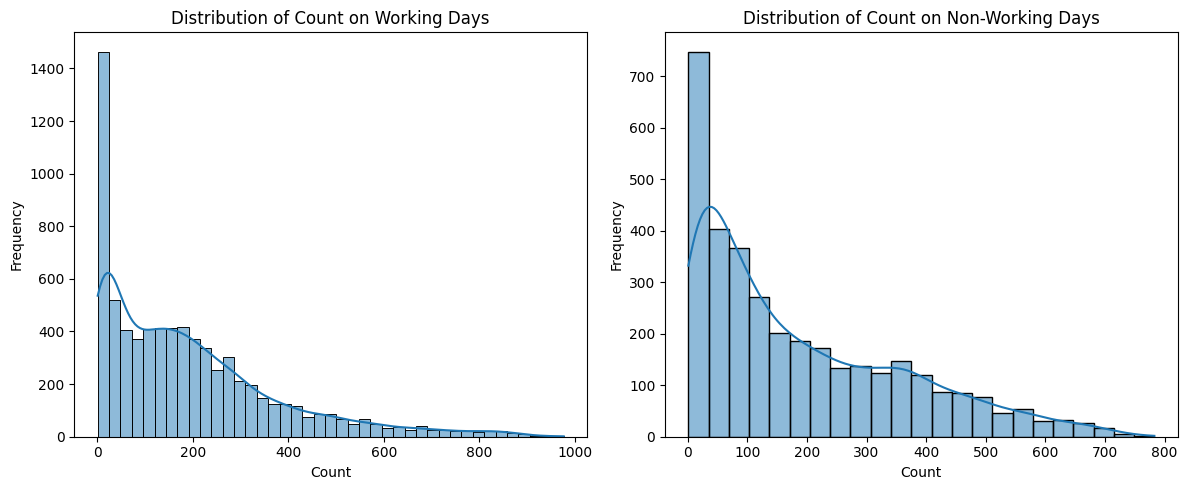

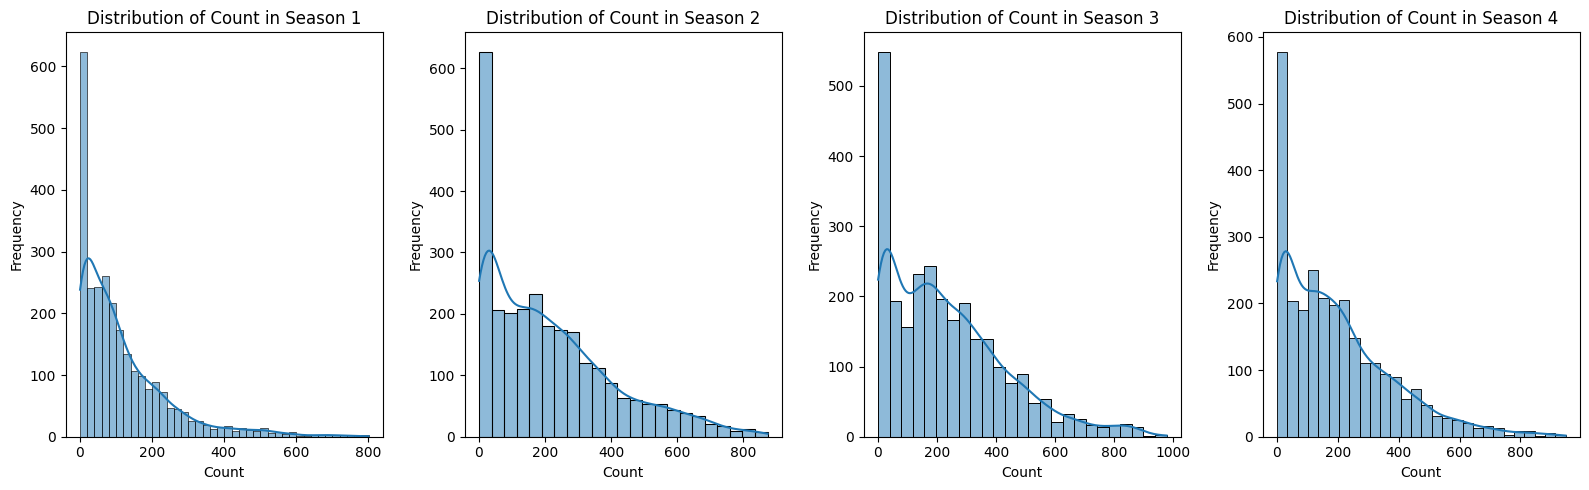

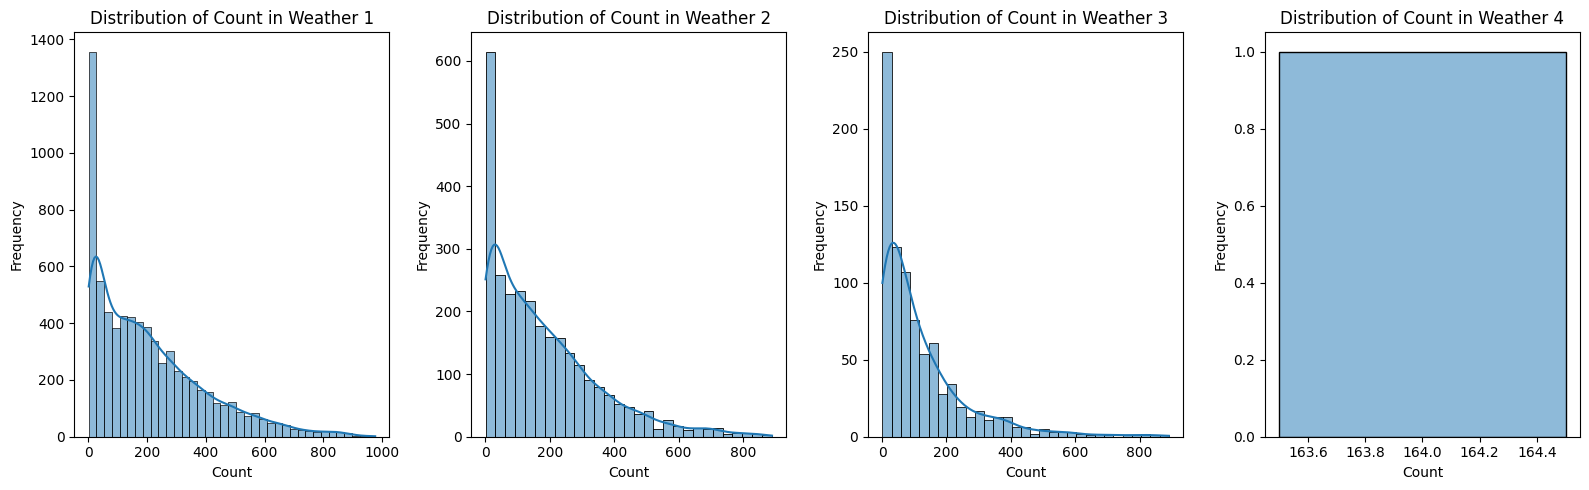

In [ ]:
# Histograms for workingday
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(workingday_counts, kde=True)
plt.title('Distribution of Count on Working Days')
plt.xlabel('Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(non_workingday_counts, kde=True)
plt.title('Distribution of Count on Non-Working Days')
plt.xlabel('Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Histograms for season
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
sns.histplot(season_1_counts, kde=True)
plt.title('Distribution of Count in Season 1')
plt.xlabel('Count')
plt.ylabel('Frequency')

plt.subplot(1, 4, 2)
sns.histplot(season_2_counts, kde=True)
plt.title('Distribution of Count in Season 2')
plt.xlabel('Count')
plt.ylabel('Frequency')

plt.subplot(1, 4, 3)
sns.histplot(season_3_counts, kde=True)
plt.title('Distribution of Count in Season 3')
plt.xlabel('Count')
plt.ylabel('Frequency')

plt.subplot(1, 4, 4)
sns.histplot(season_4_counts, kde=True)
plt.title('Distribution of Count in Season 4')
plt.xlabel('Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Histograms for weather
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
sns.histplot(weather_1_counts, kde=True)
plt.title('Distribution of Count in Weather 1')
plt.xlabel('Count')
plt.ylabel('Frequency')

plt.subplot(1, 4, 2)
sns.histplot(weather_2_counts, kde=True)
plt.title('Distribution of Count in Weather 2')
plt.xlabel('Count')
plt.ylabel('Frequency')

plt.subplot(1, 4, 3)
sns.histplot(weather_3_counts, kde=True)
plt.title('Distribution of Count in Weather 3')
plt.xlabel('Count')
plt.ylabel('Frequency')

plt.subplot(1, 4, 4)
sns.histplot(weather_4_counts, kde=True)
plt.title('Distribution of Count in Weather 4')
plt.xlabel('Count')
plt.ylabel('Frequency')


plt.tight_layout()
plt.show()

**Reasoning**:
Visually inspect the histograms to assess the normality assumption for the statistical tests.

Based on visual inspection of the histograms:

*   **Working Day vs. Count:** The distributions for both working days and non-working days are clearly right-skewed and do not appear normally distributed.
*   **Season vs. Count:** The distributions for all four seasons are also right-skewed and deviate from a normal distribution.
*   **Weather vs. Count:** The distributions for weather conditions 1, 2, and 3 are right-skewed. Weather condition 4 has only one data point, so its distribution cannot be assessed for normality.

These visual inspections suggest that the normality assumption for the t-test and ANOVA tests is likely violated.

## Check equal variance assumption

Perform Levene's test for equality of variances across groups.

**Hypotheses:**

* **Null Hypothesis (H₀):** The variances of the groups are equal.
* **Alternative Hypothesis (H₁):** The variances of at least one group are significantly different from the others.

In [ ]:
from scipy.stats import levene

# Check equal variance assumption for workingday
levene_workingday = levene(workingday_counts, non_workingday_counts)
print(f"Levene's test for workingday vs count: Statistic = {levene_workingday.statistic}, P-value = {levene_workingday.pvalue}")

# Check equal variance assumption for season
levene_season = levene(season_1_counts, season_2_counts, season_3_counts, season_4_counts)
print(f"Levene's test for season vs count: Statistic = {levene_season.statistic}, P-value = {levene_season.pvalue}")

# Check equal variance assumption for weather
levene_weather = levene(weather_1_counts, weather_2_counts, weather_3_counts, weather_4_counts)
print(f"Levene's test for weather vs count: Statistic = {levene_weather.statistic}, P-value = {levene_weather.pvalue}")

Levene's test for workingday vs count: Statistic = 0.004972848886504472, P-value = 0.9437823280916695
Levene's test for season vs count: Statistic = 187.7706624026276, P-value = 1.0147116860043298e-118
Levene's test for weather vs count: Statistic = 54.85106195954556, P-value = 3.504937946833238e-35


**Interpretation of Results:**

Based on the Levene's test results:

*   **Working Day vs. Count:** The p-value (0.944) is greater than 0.05, so we **fail to reject the null hypothesis**. This indicates that the assumption of equal variances is met for the 'workingday' groups.
*   **Season vs. Count:** The p-value (1.01e-118) is much less than 0.05, so we **reject the null hypothesis**. This indicates that the assumption of equal variances is violated across the different seasons.
*   **Weather vs. Count:** The p-value (3.50e-35) is much less than 0.05, so we **reject the null hypothesis**. This indicates that the assumption of equal variances is violated across the different weather conditions.

## Check normality assumption

Check the normality assumption for the statistical tests by visualizing the distribution of the 'count' variable for each group using Q-Q plots.


**Reasoning**:
Create Q-Q plots for the 'count' variable for each group within 'workingday', 'season', and 'weather' to check for normality visually.



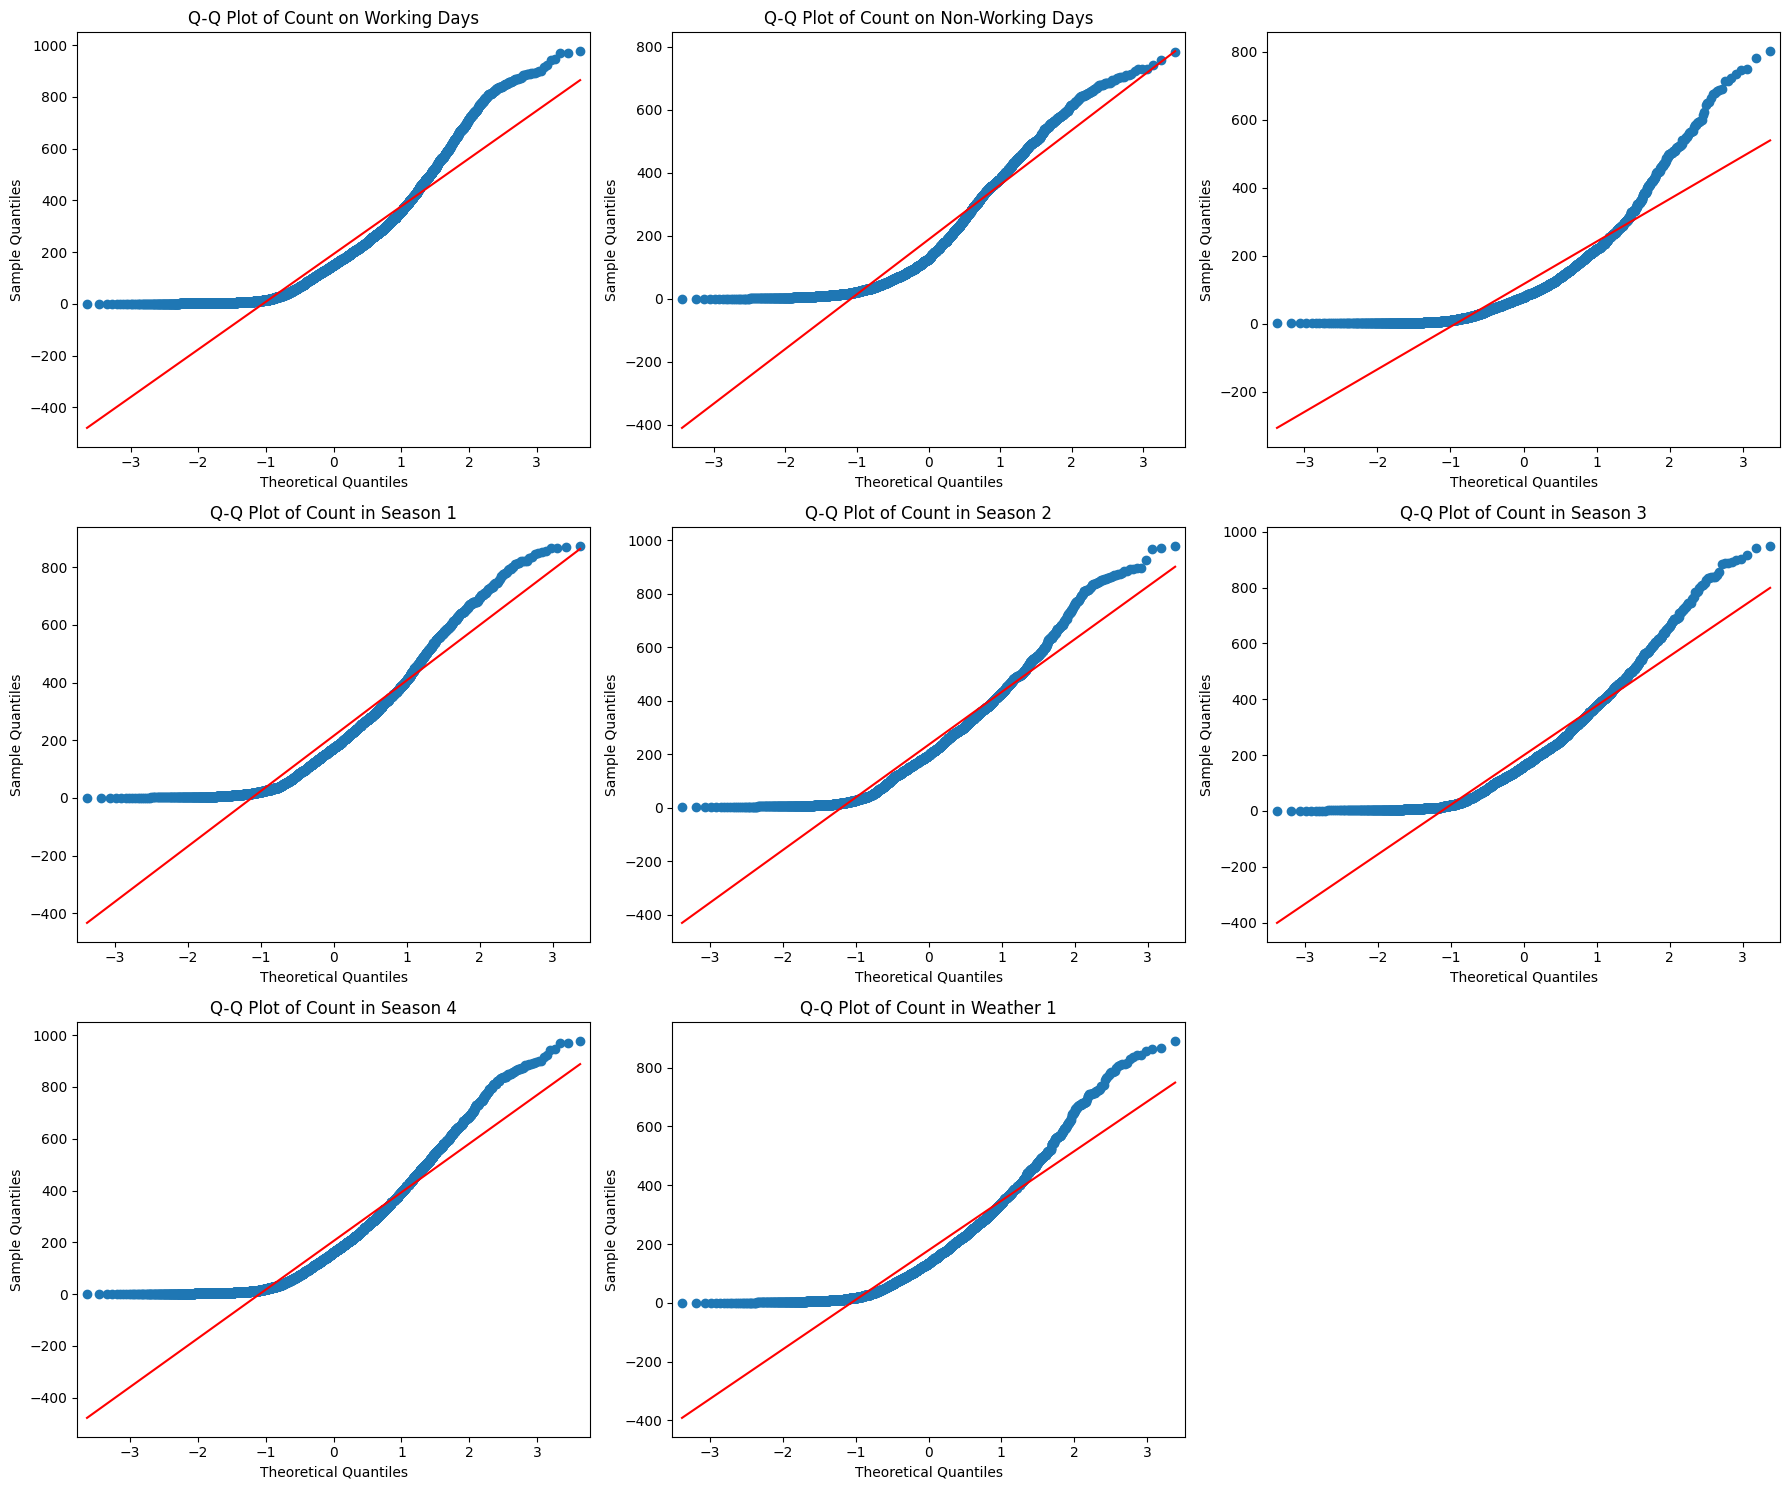

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Q-Q plots for workingday, season, and weather in a 3x3 subplot
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Working Day
sm.qqplot(workingday_counts, line='s', ax=axes[0, 0])
axes[0, 0].set_title('Q-Q Plot of Count on Working Days')

sm.qqplot(non_workingday_counts, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot of Count on Non-Working Days')

# Season
sm.qqplot(season_1_counts, line='s', ax=axes[0, 2])
axes[1, 0].set_title('Q-Q Plot of Count in Season 1')

sm.qqplot(season_2_counts, line='s', ax=axes[1, 0])
axes[1, 1].set_title('Q-Q Plot of Count in Season 2')

sm.qqplot(season_3_counts, line='s', ax=axes[1, 1])
axes[1, 2].set_title('Q-Q Plot of Count in Season 3')

sm.qqplot(season_4_counts, line='s', ax=axes[1, 2])
axes[2, 0].set_title('Q-Q Plot of Count in Season 4')

# Weather
sm.qqplot(weather_1_counts, line='s', ax=axes[2, 0])
axes[2, 1].set_title('Q-Q Plot of Count in Weather 1')

sm.qqplot(weather_2_counts, line='s', ax=axes[2, 1])
axes[2, 2].set_title('Q-Q Plot of Count in Weather 2')

# Hide any unused subplots
for i in range(3):
    for j in range(3):
        if (i, j) not in [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1)]:
            fig.delaxes(axes[i, j])


plt.tight_layout()
plt.show()

**Reasoning**:
Interpret the Q-Q plots to assess the normality assumption for the statistical tests.

Based on the Q-Q plots:

*   For all groups ('workingday', 'season', and 'weather'), the points on the Q-Q plots deviate significantly from the straight red line, especially at the tails. This indicates that the distribution of 'count' for these groups is not normal and is likely right-skewed, confirming the observations from the histograms.

This visual analysis from the Q-Q plots reinforces that the normality assumption for the t-test and ANOVA tests is violated.

## Summary:

### Data Analysis Key Findings

*   Visual inspection of histograms and Q-Q plots revealed that the distribution of the 'count' variable is right-skewed across all groups ('workingday', 'season', and 'weather'), indicating a violation of the normality assumption for the planned statistical tests.
*   Levene's test for the 'workingday' groups showed a p-value of 0.944, indicating that the equal variance assumption is met for the comparison of counts on working days versus non-working days.
*   Levene's test for the 'season' groups yielded a p-value of 1.01e-118, indicating a significant violation of the equal variance assumption across different seasons.
*   Levene's test for the 'weather' groups resulted in a p-value of 3.50e-35, indicating a significant violation of the equal variance assumption across different weather conditions.

